In [2]:
import numpy as np
from qiskit import QuantumCircuit

rng = np.random.default_rng()
bit_num = 20
qc = QuantumCircuit(bit_num, bit_num)

abits = np.round(rng.random(bit_num))

# generate Alice's random measurement bases. Here we will associate a "0" with the Z basis, and a "1" with the X basis.

abase = np.round(rng.random(bit_num))

# Alice's state preparation. Check that this creates states according to table 1

for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)

qc.barrier()

# QKD step 2: Random bases for Bob generate Bob's random measurement bases.

bbase = np.round(rng.random(bit_num))

# If Bob measures in the X basis, we implement a hadamard gate qc.h to facilitate the measurement.

for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(m, m)

Alice's bits are  [1. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1.]
Alice's bases are  [0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0.]
Bob's bases are  [0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1.]


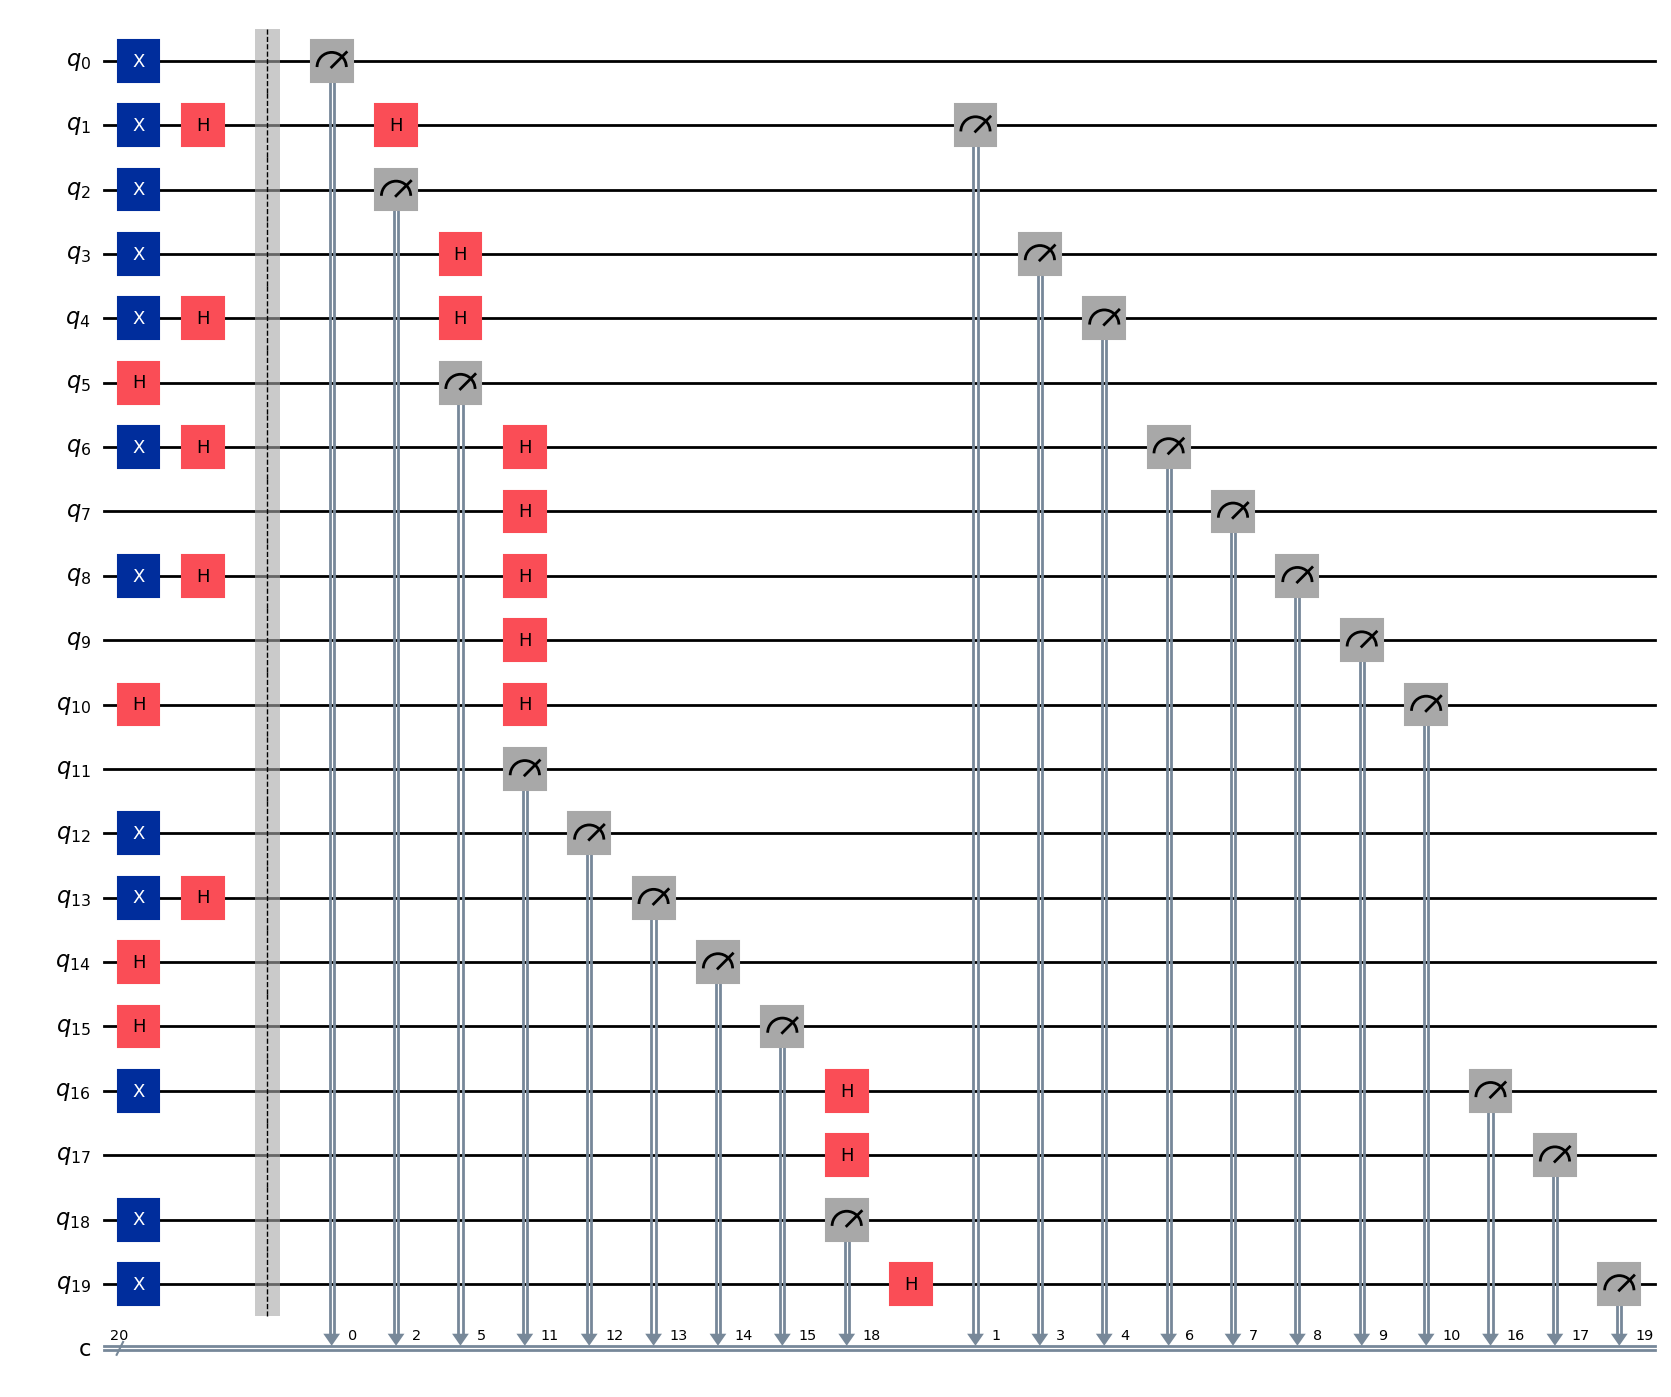

In [3]:
print("Alice's bits are ", abits)
print("Alice's bases are ", abase)
print("Bob's bases are ", bbase)
qc.draw("mpl")

In [9]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load IBM Quantum Compute Service

QiskitRuntimeService.save_account(channel='ibm_quantum_platform',
instance = 'quantum_key_distribution', token='s4EUTCKsHt_9aia2wP1o6D-9fHBu8Ia', overwrite=True, set_as_default=True)
service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Load saved credentials
service = QiskitRuntimeService()


# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
backend = service.backend("ibm_marrakesh")
print(backend.name)

ibm_marrakesh


In [17]:
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel


from qiskit_ibm_runtime import SamplerV2 as Sampler


noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [18]:
# Qiskit patterns step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

In [ ]:
sampler = Sampler(mode=backend)
job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc], shots = 1)
counts = job.result()[0].data.c.get_counts()
countsint = job.result()[0].data.c.get_int_counts()

In [ ]:
keys = counts.keys()
key = list(keys)[0]
bmeas = list(key)
bmeas_ints = []
for n in range(bit_num):
    bmeas_ints.append(int(bmeas[n]))

bbits = bmeas_ints[::-1]

print(bbits)

In [ ]:
# QKD step 3: Public discussion of bases

agoodbits = []
bgoodbits = []
match_count = 0
for n in range(bit_num):
    # Check whether bases matched.
    if abase[n] == bbase[n]:
        agoodbits.append(int(abits[n]))
        bgoodbits.append(bbits[n])
        # If bits match when bases matched, increase count of matching bits
        if int(abits[n]) == bbits[n]:
            match_count += 1

print(agoodbits)
print(bgoodbits)
print("fidelity = ", match_count / len(agoodbits))
print("loss = ", 1 - match_count / len(agoodbits))